In [1]:
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [2]:
MIN_N_DATAPOINTS: Final[int] = 2  # need at least one death and one survival
MAX_N_DATAPOINTS: Final[int] = 30
MAX_N_FEATURES: Final[int] = 10
N_TRIALS: Final[int] = 100
GROUND_TRUTH_PSURV: Final[float] = 0.50

In [3]:
avg_res_df = pd.DataFrame(
    index=pd.Index(
        name="n_datapoints",
        data=range(MIN_N_DATAPOINTS, MAX_N_DATAPOINTS+1),
    ),
    columns=pd.Index(
        name="n_features",
        # note: first feature will always be `ones`
        data=range(1, MAX_N_FEATURES+1),
    ),
    data=np.nan,
)
avg_res_df

n_features,1,2,3,4,5,6,7,8,9,10
n_datapoints,,,,,,,,,,
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
avg_model_psurv_of_observed_dier_logreg = avg_res_df.copy()
avg_model_psurv_of_observed_survivor_logreg = avg_res_df.copy()
avg_model_psurv_of_observed_dier_tree = avg_res_df.copy()
avg_model_psurv_of_observed_survivor_tree = avg_res_df.copy()

In [5]:
np.random.seed(42)
rng = np.random.default_rng()

In [6]:
for n_datapoints in avg_res_df.index:
    print(f"{n_datapoints = }")

    # note: first feature will always be `ones`
    for n_features in avg_res_df.columns:
        print(f"    {n_features = }")

        trialwise_model_psurv_of_observed_dier_logreg = np.empty(shape=N_TRIALS)
        trialwise_model_psurv_of_observed_survivor_logreg = np.empty(shape=N_TRIALS)
        trialwise_model_psurv_of_observed_dier_tree = np.empty(shape=N_TRIALS)
        trialwise_model_psurv_of_observed_survivor_tree = np.empty(shape=N_TRIALS)
        for trial in range(N_TRIALS):

            y = rng.binomial(n=1, p=GROUND_TRUTH_PSURV, size=n_datapoints)
            # hardcode the first two outcomes to be exactly one death and one survival
            y[0] = 0
            y[1] = 1
            X = rng.standard_normal(size=(n_datapoints, n_features))
            # manually account for intercept
            X[:, 0] = 1

            logreg_obj = LogisticRegression(fit_intercept=False)
            logreg_obj.fit(X, y)
            trialwise_model_psurv_of_observed_dier_logreg[trial] = logreg_obj.predict_proba(X[0:1, :])[0, 1]
            trialwise_model_psurv_of_observed_survivor_logreg[trial] = logreg_obj.predict_proba(X[1:2, :])[0, 1]

            tree_obj = DecisionTreeClassifier()
            tree_obj.fit(X, y)
            trialwise_model_psurv_of_observed_dier_tree[trial] = tree_obj.predict_proba(X[0:1, :])[0, 1]
            trialwise_model_psurv_of_observed_survivor_tree[trial] = tree_obj.predict_proba(X[1:2, :])[0, 1]

        avg_model_psurv_of_observed_dier_logreg.loc[n_datapoints, n_features] = trialwise_model_psurv_of_observed_dier_logreg.mean()
        avg_model_psurv_of_observed_survivor_logreg.loc[n_datapoints, n_features] = trialwise_model_psurv_of_observed_survivor_logreg.mean()
        avg_model_psurv_of_observed_dier_tree.loc[n_datapoints, n_features] = trialwise_model_psurv_of_observed_dier_tree.mean()
        avg_model_psurv_of_observed_survivor_tree.loc[n_datapoints, n_features] = trialwise_model_psurv_of_observed_survivor_tree.mean()

n_datapoints = 2
    n_features = 1
    n_features = 2
    n_features = 3
    n_features = 4
    n_features = 5
    n_features = 6
    n_features = 7
    n_features = 8
    n_features = 9
    n_features = 10
n_datapoints = 3
    n_features = 1
    n_features = 2
    n_features = 3
    n_features = 4
    n_features = 5
    n_features = 6
    n_features = 7
    n_features = 8
    n_features = 9
    n_features = 10
n_datapoints = 4
    n_features = 1
    n_features = 2
    n_features = 3
    n_features = 4
    n_features = 5
    n_features = 6
    n_features = 7
    n_features = 8
    n_features = 9
    n_features = 10
n_datapoints = 5
    n_features = 1
    n_features = 2
    n_features = 3
    n_features = 4
    n_features = 5
    n_features = 6
    n_features = 7
    n_features = 8
    n_features = 9
    n_features = 10
n_datapoints = 6
    n_features = 1
    n_features = 2
    n_features = 3
    n_features = 4
    n_features = 5
    n_features = 6
    n_features = 7
    n_features = 8

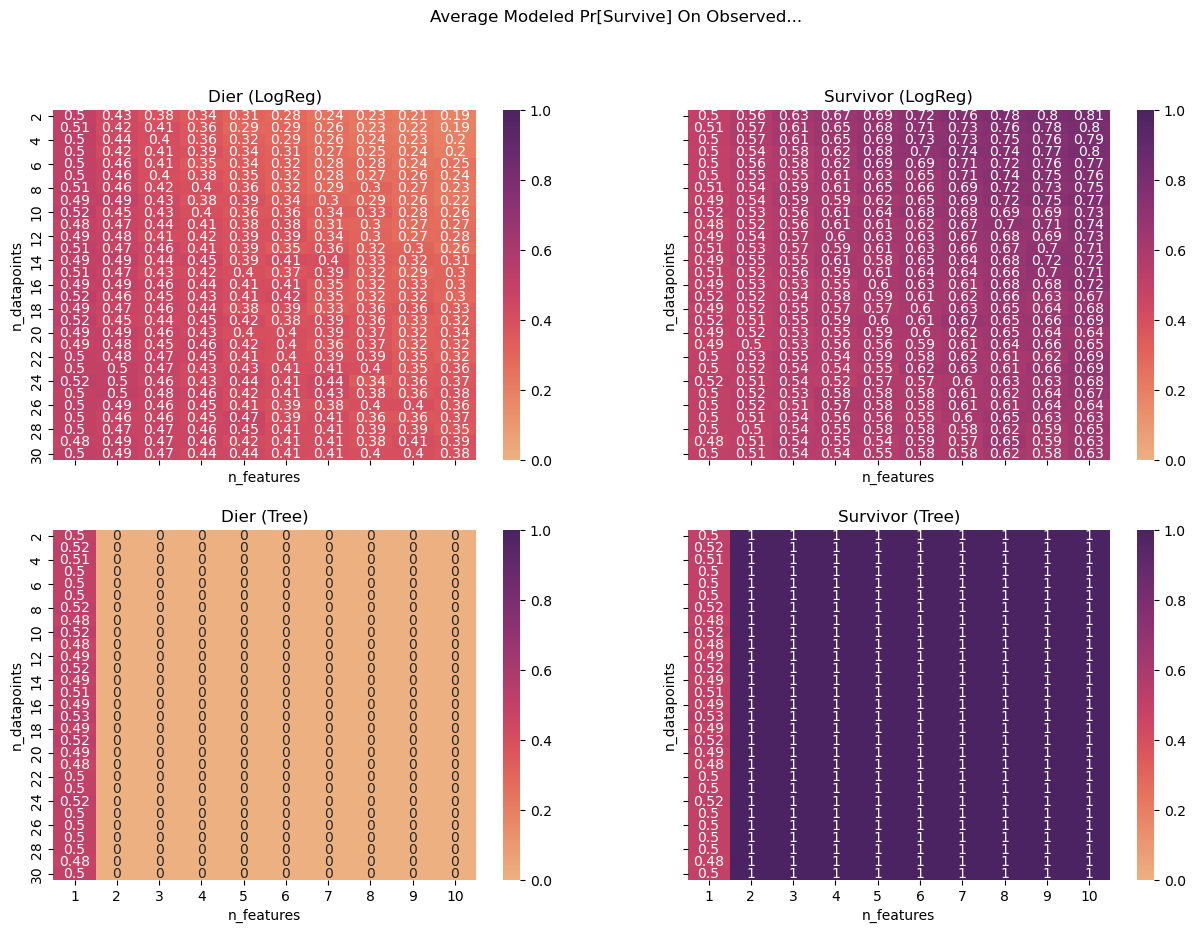

In [7]:
fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(15, 10))
plt.suptitle("Average Modeled Pr[Survive] On Observed...")
for ax, title, data in [
    (axs[0,0], "Dier (LogReg)", avg_model_psurv_of_observed_dier_logreg),
    (axs[0,1], "Survivor (LogReg)", avg_model_psurv_of_observed_survivor_logreg),
    (axs[1,0], "Dier (Tree)", avg_model_psurv_of_observed_dier_tree),
    (axs[1,1], "Survivor (Tree)", avg_model_psurv_of_observed_survivor_tree),
]:
    ax.set_title(title)
    sns.heatmap(
        ax=ax,
        data=data,
        vmin=0,
        vmax=1,
        cmap=sns.color_palette("flare", as_cmap=True),
        annot=True,
    )
plt.show()